<!-- reader-content -->

# Gradient and Jacobian

## Start small

A scalar loss has a gradient. A vector residual has a Jacobian. Both pass
through the same public `Chip.with_params()` call.

In [1]:
import jax
import jax.numpy as jnp

from quchip import Capacitive, Chip, DuffingTransmon, Resonator
from quchip.backend.dynamiqs import DynamiqsBackend

q = DuffingTransmon(freq=5.0, anharmonicity=-0.25, levels=4, label="q")
r = Resonator(freq=7.0, levels=4, label="r")
chip = Chip(
    [q, r],
    [Capacitive(q, r, g=0.05, label="qr")],
    frame="rotating",
    backend=DynamiqsBackend(),
)

names = ["q.freq", "q.anharmonicity", "qr.g"]
theta = jnp.array([5.0, -0.25, 0.05])
target = jnp.array([5.05, -0.0010])


def observables(th):
    c = chip.with_params(dict(zip(names, th)))
    chi = c.dispersive_shift("q", "r") / 2
    return jnp.stack([jnp.asarray(c.freq("q")), jnp.asarray(chi)])


def residual(th):
    return observables(th) - target


def loss(th):
    return jnp.sum(residual(th) ** 2)


{
    "observables_f01_chi": observables(theta),
    "gradient": jax.grad(loss)(theta),
    "jacobian": jax.jacrev(residual)(theta),
}

{'observables_f01_chi': Array([ 4.99853347e+00, -1.43010024e-04], dtype=float64),
 'gradient': Array([-1.02871002e-01, -2.85237283e-06,  6.02561564e-03], dtype=float64),
 'jacobian': Array([[ 9.99395008e-01,  3.62188602e-05, -5.86342171e-02],
        [-1.29839799e-04,  5.10942405e-04, -5.70796457e-03]],      dtype=float64)}

<!-- simple-example-end -->

## Expand to a driven chip

This notebook reproduces the one-pulse gradient in Fig. 6 of the talk. It
differentiates the final excited-state population with respect to pulse
amplitude, Gaussian shape, and detuning.

The dynamiqs backend keeps these declared parameters differentiable through
the time-domain solve. Install it with `pip install 'quchip[dynamiqs]'`.

In [2]:
import json

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from quchip import RWA, ChargeDrive, Chip, DuffingTransmon, Gaussian, QuantumSequence

amplitude0 = 0.029
frequency0 = 5.0
sigmas0 = 3.0

qubit = DuffingTransmon(
    freq=frequency0,
    anharmonicity=-0.30,
    levels=3,
    label="q",
)
chip = Chip(
    [qubit],
    frame="rotating",
    approximation=RWA(),
    backend="dynamiqs",
)
drive = ChargeDrive(qubit, label="xy")
chip.wire(drive)

sequence = QuantumSequence(chip)
sequence.schedule(
    drive,
    envelope=Gaussian(duration=40.0, sigmas=sigmas0, amplitude=amplitude0),
    freq=frequency0,
)
times = jnp.linspace(0.0, 60.0, 121)

## Name the physical perturbations

One unit in the perturbation vector means $1\%$ in pulse amplitude, $1\%$ in
the Gaussian parameter $N_\sigma$, or $1$ MHz in pulse detuning. quchip defines
$\sigma=\mathrm{duration}/(2N_\sigma)$, so increasing $N_\sigma$ by $1\%$
narrows the physical Gaussian width by about $1\%$. The derivatives predict
changes in final population on these three scales.

`with_params()` returns a rebound sequence. It does not mutate the declared
sequence.

In [3]:
parameter_paths = ("pulse.0.amplitude", "pulse.0.sigmas", "pulse.0.freq")
perturbation_labels = (
    "amplitude (+1%)",
    r"$N_\sigma$ (+1%; $\sigma$ -1%)",
    "detuning (+1 MHz)",
)


def final_population(perturbation):
    rebound = sequence.with_params(
        {
            "pulse.0.amplitude": amplitude0 * (1.0 + 0.01 * perturbation[0]),
            "pulse.0.sigmas": sigmas0 * (1.0 + 0.01 * perturbation[1]),
            "pulse.0.freq": frequency0 + perturbation[2] * 1.0e-3,
        }
    )
    result = rebound.simulate(
        tlist=times,
        initial_state={"q": 0},
        check_truncation=False,
        partition=False,
    )
    return jnp.real(result.population("q", level=1)[-1])

## Differentiate the solve

The output is one scalar. `jax.grad` returns one derivative for each input,
while `jax.value_and_grad` evaluates the population and its gradient together.

In [4]:
origin = jnp.zeros(3)
population0, gradient = jax.jit(jax.value_and_grad(final_population))(origin)

gradient

Array([ 0.00157614, -0.00156723,  0.00337811], dtype=float64)

At this slightly under-rotated operating point, increasing the amplitude or
detuning raises the final population. Increasing $N_\sigma$ narrows the
Gaussian and lowers the final population.

## Check the derivative independently

Automatic differentiation should agree with a numerical derivative, but a
single finite-difference step can agree accidentally. We halve the step four
times and check convergence for every parameter.

In [5]:
steps = jnp.asarray([0.5, 0.25, 0.125, 0.0625, 0.03125])
directions = jnp.eye(3)


@jax.jit
def central_differences(step):
    return jax.vmap(
        lambda direction: (
            final_population(step * direction) - final_population(-step * direction)
        )
        / (2.0 * step)
    )(directions)


finite_differences = jnp.stack([central_differences(step) for step in steps])
relative_errors = jnp.abs(finite_differences - gradient) / jnp.maximum(jnp.abs(gradient), 1.0e-12)

## See the local derivative and its check

The upper panel compares the predicted population changes with central finite
differences. The lower panel plots their relative error across step sizes.

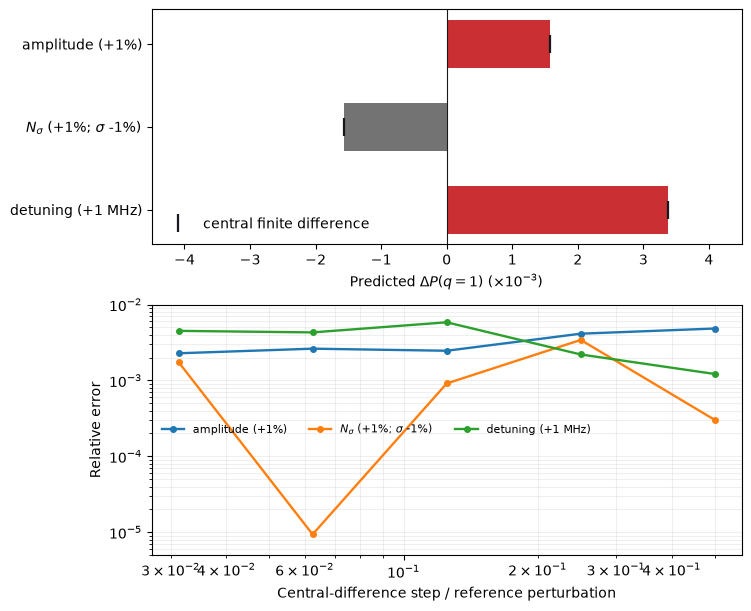

In [6]:
impact_milliprobability = np.asarray(gradient) * 1.0e3
finite_difference_check = np.asarray(finite_differences[0]) * 1.0e3
positions = np.arange(len(perturbation_labels))

figure, (impact_axis, convergence_axis) = plt.subplots(
    2,
    1,
    figsize=(7.4, 6.0),
    height_ratios=(1.5, 1.6),
    layout="constrained",
)

impact_axis.barh(
    positions,
    impact_milliprobability,
    color=["#C92F33" if value >= 0.0 else "0.45" for value in impact_milliprobability],
    height=0.58,
)
impact_axis.plot(
    finite_difference_check,
    positions,
    linestyle="none",
    marker="|",
    color="#16181C",
    markersize=13,
    markeredgewidth=1.6,
    label="central finite difference",
)
impact_axis.axvline(0.0, color="#16181C", linewidth=0.8)
impact_axis.set(
    yticks=positions,
    yticklabels=perturbation_labels,
    xlabel=r"Predicted $\Delta P(q=1)$ ($\times 10^{-3}$)",
    xlim=(-4.5, 4.5),
)
impact_axis.invert_yaxis()
impact_axis.legend(frameon=False, loc="lower left")

for index, label in enumerate(perturbation_labels):
    convergence_axis.loglog(
        np.asarray(steps),
        np.asarray(relative_errors[:, index]),
        marker="o",
        linewidth=1.7,
        markersize=4.0,
        label=label,
    )
convergence_axis.set(
    xlabel="Central-difference step / reference perturbation",
    ylabel="Relative error",
    ylim=(5.0e-6, 1.0e-2),
)
convergence_axis.grid(alpha=0.2, which="both")
convergence_axis.legend(frameon=False, ncols=3, fontsize=8)

figure_path = "../docs/images/differentiate_a_driven_chip.png"
figure.savefig(figure_path, dpi=180)
plt.show()

The receipt puts all three derivatives on their reference-perturbation scales
and records the worst relative disagreement across the finite-difference
steps. Only first derivatives are checked here.

In [7]:
reference_result = sequence.simulate(
    tlist=times,
    initial_state={"q": 0},
    check_truncation=False,
    partition=False,
)

gradient_receipt = {
    "backend": "dynamiqs",
    "base_population": float(population0),
    "figure": figure_path,
    "first_order_only": True,
    "fixed_structure_during_trace": True,
    "gradient_per_reference_perturbation": {
        path: float(value) for path, value in zip(parameter_paths, gradient)
    },
    "maximum_relative_error_across_steps": float(np.max(relative_errors)),
    "original_sequence_unchanged": dict(sequence.parameters)
    == {
        "q.freq": frequency0,
        "q.anharmonicity": -0.30,
        "pulse.0.freq": frequency0,
        "pulse.0.phase": 0.0,
        "pulse.0.start_time": None,
        "pulse.0.duration": 40.0,
        "pulse.0.sigmas": sigmas0,
        "pulse.0.amplitude": amplitude0,
    },
    "parameter_paths": list(parameter_paths),
    "solver": reference_result.solver,
}

print(f"RESULT gradient={json.dumps(gradient_receipt, sort_keys=True, separators=(',', ':'))}")

RESULT gradient={"backend":"dynamiqs","base_population":0.99551809283684,"figure":"../docs/images/differentiate_a_driven_chip.png","first_order_only":true,"fixed_structure_during_trace":true,"gradient_per_reference_perturbation":{"pulse.0.amplitude":0.0015761406257590448,"pulse.0.freq":0.003378107041808197,"pulse.0.sigmas":-0.001567228852927645},"maximum_relative_error_across_steps":0.005832718427203168,"original_sequence_unchanged":true,"parameter_paths":["pulse.0.amplitude","pulse.0.sigmas","pulse.0.freq"],"solver":"sesolve"}


## Boundaries of this gradient

The traced calculation keeps the device graph, Hilbert-space dimensions, and
RWA band selection fixed. dynamiqs supports this automatic-differentiation
path; QuTiP remains available for ordinary solves and sweeps but does not
provide gradients. Eigenvector derivatives also require care near degenerate
subspaces.

## What to change

Replace the returned population with any scalar objective to obtain its
gradient. If the output is a time trace or a batch instead, use `jax.jacrev`
or `jax.jacfwd` to obtain its Jacobian. Keep an independent finite-difference
spot check when introducing a new objective or parameter path.